In [1]:
from pathlib import Path
import csv, json, re, cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path("/homes/mxqasim/Chocolathon")
RAW_DIR = PROJECT_ROOT / "data/boxes/raw"
BOX_ANNOTATION_DIR = PROJECT_ROOT / "data/boxes/annotations"
SYNTH_ROOT = PROJECT_ROOT / "data/synthetic_filled_boxes/v4"
EXPERIMENT_DIR = PROJECT_ROOT / "data/experiments/tray_segmentation_v1"
EXPERIMENT_DIR.mkdir(parents=True, exist_ok=True)

CORNER_NAMES = ["top_left", "top_right", "bottom_right", "bottom_left"]
HELD_OUT = {"IMG_2021.jpg", "IMG_2026.jpg", "IMG_2030.jpg", "IMG_2034.jpg"}

def parse_corners(value):
    if isinstance(value, str): value = json.loads(value)
    if isinstance(value, dict): return np.asarray([value[name] for name in CORNER_NAMES], np.float32)
    return np.asarray(value, np.float32).reshape(4, 2)

def resolve_path(value, base):
    if not value: raise ValueError("Missing image path")
    path = Path(value)
    for candidate in (path, base / path, PROJECT_ROOT / path):
        if candidate.exists(): return candidate.resolve()
    raise FileNotFoundError(value)

records = []

# Original boxes: raw images with manually annotated physical tray corners.
for annotation_path in sorted(BOX_ANNOTATION_DIR.glob("*.json")):
    annotation = json.loads(annotation_path.read_text())
    source_file = annotation["file"]
    image_path = RAW_DIR / source_file
    records.append({
        "image_path": str(image_path.resolve()),
        "source_file": source_file,
        "capacity": int(annotation["box_size"]),
        "kind": "original_empty",
        "corners": json.dumps(parse_corners(annotation["corners"]).tolist())
    })

# Synthetic boxes: use the exact tray corners stored during rendering.
with (SYNTH_ROOT / "manifest.csv").open(newline="") as f:
    for row in csv.DictReader(f):
        image_path = resolve_path(row.get("image") or row.get("image_path") or row.get("file"), SYNTH_ROOT)
        source_file = (row.get("source_file") or "").strip()

        if not source_file:
            match = re.search(r"IMG_\d+", image_path.name)
            if not match: raise ValueError(f"Cannot determine source file from {image_path.name}")
            source_file = match.group(0) + ".jpg"

        corner_value = row.get("corners") or row.get("corners_cam") or row.get("box_corners")
        capacity_value = row.get("box_size") or row.get("capacity")
        if not corner_value: raise ValueError(f"Missing corners for {image_path.name}")
        if not capacity_value: raise ValueError(f"Missing capacity for {image_path.name}")

        records.append({
            "image_path": str(image_path),
            "source_file": source_file,
            "capacity": int(capacity_value),
            "kind": "synthetic_filled",
            "corners": json.dumps(parse_corners(corner_value).tolist())
        })

records = pd.DataFrame(records)
records["split"] = records["source_file"].map(lambda name: "validation" if name in HELD_OUT else "train")
records.to_csv(EXPERIMENT_DIR / "segmentation_records.csv", index=False)

missing = records.loc[~records["image_path"].map(lambda path: Path(path).exists())]

print("Records:", len(records))
print("Training:", (records["split"] == "train").sum())
print("Validation:", (records["split"] == "validation").sum())
print("\nRecords by split, capacity and kind:")
print(records.groupby(["split", "capacity", "kind"]).size())
print("\nMissing images:", len(missing))

assert len(records) == 64, f"Expected 64 records, found {len(records)}"
assert missing.empty, missing[["image_path"]]
assert set(records["capacity"]) == {6, 16, 30, 50}

print("\nPASS: true tray-corner annotations loaded")

Records: 64
Training: 48
Validation: 16

Records by split, capacity and kind:
split       capacity  kind            
train       6         original_empty       2
                      synthetic_filled     6
            16        original_empty       4
                      synthetic_filled    12
            30        original_empty       3
                      synthetic_filled     9
            50        original_empty       3
                      synthetic_filled     9
validation  6         original_empty       1
                      synthetic_filled     3
            16        original_empty       1
                      synthetic_filled     3
            30        original_empty       1
                      synthetic_filled     3
            50        original_empty       1
                      synthetic_filled     3
dtype: int64

Missing images: 0

PASS: true tray-corner annotations loaded


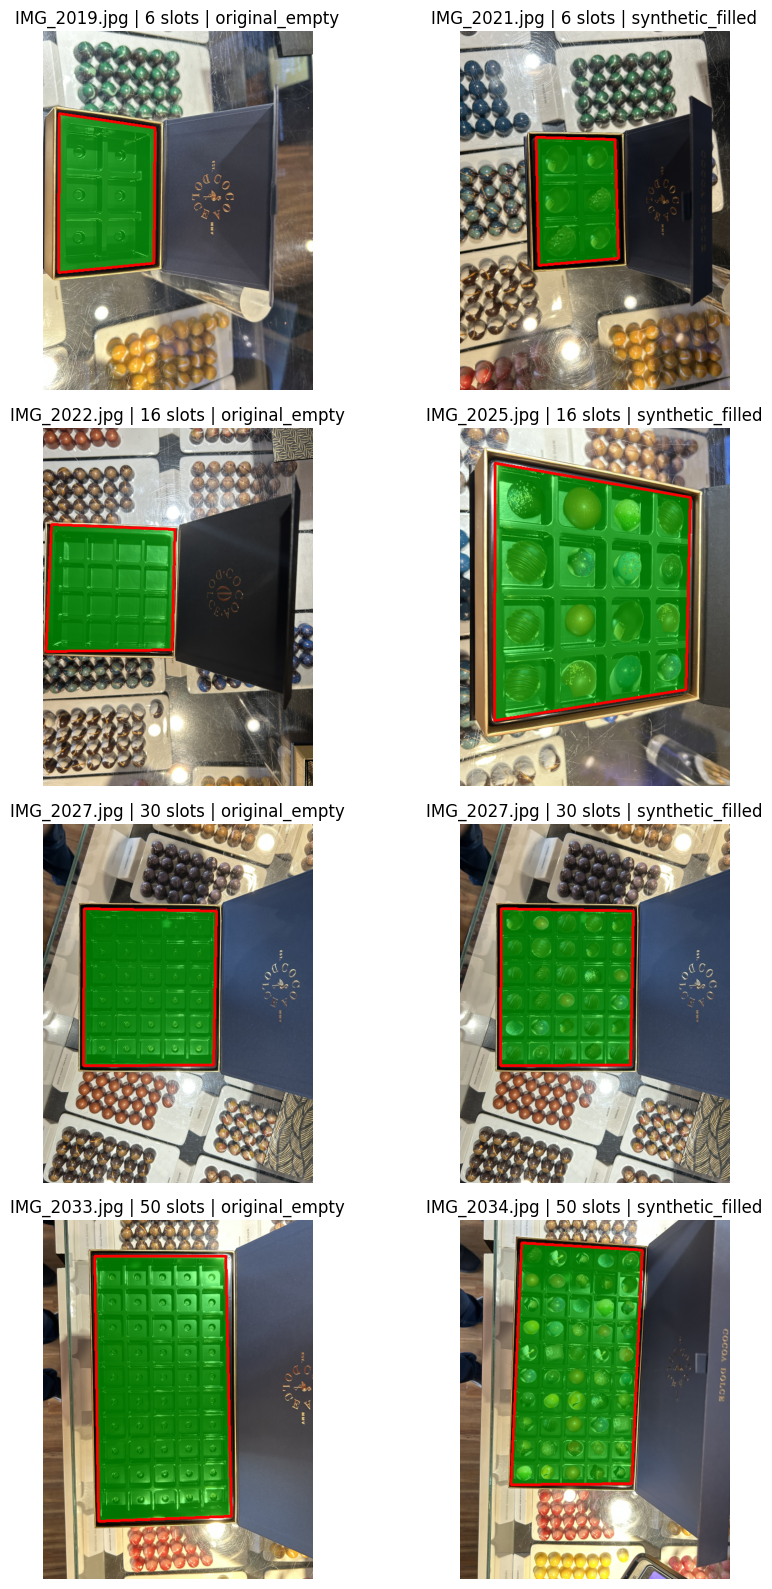

Validated true tray polygons: 64
Previewed examples: 8
PASS: outer tray masks are valid
The green mask should now extend to the manually clicked tray boundary


In [2]:
def load_image_corners(record):
    bgr = cv2.imread(record.image_path)
    if bgr is None: raise ValueError(f"Cannot decode {record.image_path}")

    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    h, w = rgb.shape[:2]
    corners = parse_corners(record.corners)

    if corners[:, 0].max() <= 1.5 and corners[:, 1].max() <= 1.5:
        corners *= np.array([w, h], np.float32)

    valid = (
        (corners[:, 0] >= 0).all() and (corners[:, 0] < w).all() and
        (corners[:, 1] >= 0).all() and (corners[:, 1] < h).all()
    )
    if not valid: raise ValueError(f"Corners outside image: {record.image_path}")

    return rgb, corners

def create_preview(record, maximum_side=650):
    rgb, corners = load_image_corners(record)
    h, w = rgb.shape[:2]
    scale = min(maximum_side / max(h, w), 1.0)
    preview_size = (max(1, round(w * scale)), max(1, round(h * scale)))
    preview = cv2.resize(rgb, preview_size, interpolation=cv2.INTER_AREA)
    preview_corners = corners * scale
    polygon = np.round(preview_corners).astype(np.int32)

    mask = np.zeros(preview.shape[:2], np.uint8)
    cv2.fillConvexPoly(mask, polygon, 255)

    overlay = preview.copy()
    overlay[mask > 0] = (
        0.55 * overlay[mask > 0] + 0.45 * np.array([0, 255, 0])
    ).astype(np.uint8)
    cv2.polylines(overlay, [polygon], True, (255, 0, 0), 3)
    return overlay

validation_errors = []

for record in records.itertuples(index=False):
    try:
        rgb, corners = load_image_corners(record)
        h, w = rgb.shape[:2]
        polygon = np.round(corners).astype(np.int32)
        area_ratio = cv2.contourArea(polygon) / float(w * h)

        if not cv2.isContourConvex(polygon):
            validation_errors.append((Path(record.image_path).name, "non-convex polygon"))
        elif not 0.02 < area_ratio < 0.95:
            validation_errors.append((Path(record.image_path).name, f"area ratio={area_ratio:.4f}"))

        del rgb
    except Exception as error:
        validation_errors.append((Path(record.image_path).name, str(error)))

assert not validation_errors, validation_errors

sample_parts = []
for capacity in [6, 16, 30, 50]:
    for kind in ["original_empty", "synthetic_filled"]:
        candidates = records[(records["capacity"] == capacity) & (records["kind"] == kind)]
        sample_parts.append(candidates.sample(1, random_state=capacity))

samples = pd.concat(sample_parts, ignore_index=True)
fig, axes = plt.subplots(4, 2, figsize=(10, 16))

for axis, record in zip(axes.flat, samples.itertuples(index=False)):
    overlay = create_preview(record)
    axis.imshow(overlay)
    axis.set_title(f"{record.source_file} | {record.capacity} slots | {record.kind}")
    axis.axis("off")
    del overlay

plt.tight_layout()
plt.show()
plt.close(fig)

print("Validated true tray polygons:", len(records))
print("Previewed examples:", len(samples))
print("PASS: outer tray masks are valid")
print("The green mask should now extend to the manually clicked tray boundary")

In [4]:
from pathlib import Path
import json

BOX_ROOT = Path("/homes/mxqasim/Chocolathon/data/boxes")
matches = sorted(BOX_ROOT.rglob("IMG_2019.json"))

print("IMG_2019 annotation files found:", len(matches))

for path in matches:
    print("\n" + "=" * 100)
    print(path)
    data = json.loads(path.read_text())
    print(json.dumps(data, indent=2)[:3000])

IMG_2019 annotation files found: 2

/homes/mxqasim/Chocolathon/data/boxes/annotations/IMG_2019.json
{
  "file": "IMG_2019.jpg",
  "box_size": 6,
  "image_width": 3024,
  "image_height": 4032,
  "corners": {
    "top_left": [
      181.44000244140625,
      924.8099975585938
    ],
    "top_right": [
      1252.800048828125,
      1084.7099609375
    ],
    "bottom_right": [
      1239.8399658203125,
      2605.889892578125
    ],
    "bottom_left": [
      172.8000030517578,
      2709.610107421875
    ]
  }
}

/homes/mxqasim/Chocolathon/data/boxes/grid_annotations/IMG_2019.json
{
  "file": "IMG_2019.jpg",
  "box_size": 6,
  "rows": 3,
  "columns": 2,
  "anchors": {
    "top_left": [
      85.0,
      174.0
    ],
    "top_right": [
      299.0,
      178.0
    ],
    "bottom_right": [
      300.0,
      600.0
    ],
    "bottom_left": [
      95.0,
      601.0
    ]
  }
}


In [5]:
import random, time
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision.models import efficientnet_b0

SEED, INPUT_SIZE, BATCH_SIZE = 42, 320, 4
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.set_num_threads(1)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BACKBONE_PATH = PROJECT_ROOT / "data/experiments/box_localization_v2/deployment/efficientnet_b0_box_size_classifier.pt"
MODEL_PATH = EXPERIMENT_DIR / "efficientnet_b0_tray_segmenter_candidate.pt"

class TrayDataset(Dataset):
    def __init__(self, frame, training=False):
        self.frame = frame.reset_index(drop=True)
        self.training = training

    def __len__(self): return len(self.frame)

    def __getitem__(self, index):
        record = self.frame.iloc[index]
        rgb, corners = load_image_corners(record)
        h, w = rgb.shape[:2]
        mask = np.zeros((h, w), np.uint8)
        cv2.fillConvexPoly(mask, np.round(corners).astype(np.int32), 255)

        rgb = cv2.resize(rgb, (INPUT_SIZE, INPUT_SIZE), interpolation=cv2.INTER_AREA)
        mask = cv2.resize(mask, (INPUT_SIZE, INPUT_SIZE), interpolation=cv2.INTER_NEAREST)

        if self.training:
            if random.random() < 0.5:
                rgb, mask = np.ascontiguousarray(rgb[:, ::-1]), np.ascontiguousarray(mask[:, ::-1])

            angle, scale = random.uniform(-12, 12), random.uniform(0.88, 1.12)
            tx, ty = random.uniform(-0.06, 0.06) * INPUT_SIZE, random.uniform(-0.06, 0.06) * INPUT_SIZE
            matrix = cv2.getRotationMatrix2D((INPUT_SIZE / 2, INPUT_SIZE / 2), angle, scale)
            matrix[:, 2] += (tx, ty)
            rgb = cv2.warpAffine(rgb, matrix, (INPUT_SIZE, INPUT_SIZE), flags=cv2.INTER_LINEAR, borderMode=cv2.BORDER_REFLECT_101)
            mask = cv2.warpAffine(mask, matrix, (INPUT_SIZE, INPUT_SIZE), flags=cv2.INTER_NEAREST, borderMode=cv2.BORDER_CONSTANT)

            if random.random() < 0.7:
                alpha, beta = random.uniform(0.75, 1.25), random.uniform(-25, 25)
                rgb = np.clip(rgb.astype(np.float32) * alpha + beta, 0, 255).astype(np.uint8)

        image = torch.from_numpy(rgb.copy()).permute(2, 0, 1).float().div(255)
        image = (image - torch.tensor([0.485, 0.456, 0.406])[:, None, None]) / torch.tensor([0.229, 0.224, 0.225])[:, None, None]
        target = torch.from_numpy((mask > 127).astype(np.float32))[None]
        return image, target, record["image_path"], int(record["capacity"])

class ConvBlock(nn.Sequential):
    def __init__(self, input_channels, output_channels):
        super().__init__(
            nn.Conv2d(input_channels, output_channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(output_channels), nn.SiLU(inplace=True),
            nn.Conv2d(output_channels, output_channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(output_channels), nn.SiLU(inplace=True)
        )

class UpBlock(nn.Module):
    def __init__(self, input_channels, skip_channels, output_channels):
        super().__init__()
        self.block = ConvBlock(input_channels + skip_channels, output_channels)

    def forward(self, x, skip):
        x = F.interpolate(x, size=skip.shape[-2:], mode="bilinear", align_corners=False)
        return self.block(torch.cat([x, skip], dim=1))

class TraySegmenter(nn.Module):
    def __init__(self, backbone_path):
        super().__init__()
        self.encoder = efficientnet_b0(weights=None).features
        checkpoint = torch.load(backbone_path, map_location="cpu")
        if isinstance(checkpoint, dict) and "state_dict" in checkpoint: checkpoint = checkpoint["state_dict"]
        if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint: checkpoint = checkpoint["model_state_dict"]
        checkpoint = {k.removeprefix("module."): v for k, v in checkpoint.items()}
        encoder_state = {k[len("features."):]: v for k, v in checkpoint.items() if k.startswith("features.")}
        load_result = self.encoder.load_state_dict(encoder_state, strict=False)
        if len(encoder_state) == 0: raise ValueError(f"No EfficientNet feature weights found in {backbone_path}")

        self.up16 = UpBlock(1280, 112, 256)
        self.up8 = UpBlock(256, 40, 128)
        self.up4 = UpBlock(128, 24, 64)
        self.up2 = UpBlock(64, 16, 32)
        self.head = nn.Sequential(
            nn.Conv2d(32, 16, 3, padding=1, bias=False),
            nn.BatchNorm2d(16), nn.SiLU(inplace=True),
            nn.Conv2d(16, 1, 1)
        )
        print("Loaded encoder tensors:", len(encoder_state))
        print("Encoder missing keys:", len(load_result.missing_keys))

    def forward(self, x):
        input_size = x.shape[-2:]
        skips = {}

        for index, layer in enumerate(self.encoder):
            x = layer(x)
            if index in {1, 2, 3, 5}: skips[index] = x

        x = self.up16(x, skips[5])
        x = self.up8(x, skips[3])
        x = self.up4(x, skips[2])
        x = self.up2(x, skips[1])
        x = F.interpolate(x, size=input_size, mode="bilinear", align_corners=False)
        return self.head(x)

train_dataset = TrayDataset(records[records["split"] == "train"], training=True)
validation_dataset = TrayDataset(records[records["split"] == "validation"], training=False)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
validation_loader = DataLoader(validation_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

model = TraySegmenter(BACKBONE_PATH).to(DEVICE)
images, masks, paths, capacities = next(iter(train_loader))

with torch.no_grad():
    outputs = model(images.to(DEVICE))

print("Device:", DEVICE)
print("Training images:", len(train_dataset))
print("Validation images:", len(validation_dataset))
print("Input:", tuple(images.shape))
print("Masks:", tuple(masks.shape))
print("Output:", tuple(outputs.shape))
print("Parameters:", f"{sum(p.numel() for p in model.parameters()):,}")
assert outputs.shape == masks.shape
print("PASS: shared tray-segmentation model is ready")

/homes/mxqasim/Chocolathon/.venv/lib64/python3.9/site-packages/networkx/utils/backends.py:135: RuntimeWarning: networkx backend defined more than once: nx-loopback
  backends.update(_get_backends("networkx.backends"))


Loaded encoder tensors: 358
Encoder missing keys: 0
Device: cpu
Training images: 48
Validation images: 16
Input: (4, 3, 320, 320)
Masks: (4, 1, 320, 320)
Output: (4, 1, 320, 320)
Parameters: 8,456,237
PASS: shared tray-segmentation model is ready


In [6]:
def segmentation_loss(logits, targets):
    bce = F.binary_cross_entropy_with_logits(logits, targets)
    probabilities = logits.sigmoid()
    intersection = (probabilities * targets).sum((1, 2, 3))
    dice_loss = 1 - ((2 * intersection + 1) / (probabilities.sum((1, 2, 3)) + targets.sum((1, 2, 3)) + 1)).mean()
    return bce + dice_loss

@torch.no_grad()
def evaluate_segmentation():
    model.eval()
    total_loss, total_iou, total_dice, count = 0, 0, 0, 0

    for images, targets, _, _ in validation_loader:
        images, targets = images.to(DEVICE), targets.to(DEVICE)
        logits = model(images)
        predictions = logits.sigmoid() >= 0.5
        target_binary = targets >= 0.5
        intersection = (predictions & target_binary).sum((1, 2, 3)).float()
        union = (predictions | target_binary).sum((1, 2, 3)).float()
        predicted_area = predictions.sum((1, 2, 3)).float()
        target_area = target_binary.sum((1, 2, 3)).float()
        batch_size = images.size(0)

        total_loss += segmentation_loss(logits, targets).item() * batch_size
        total_iou += ((intersection + 1) / (union + 1)).sum().item()
        total_dice += ((2 * intersection + 1) / (predicted_area + target_area + 1)).sum().item()
        count += batch_size

    return {"loss": total_loss / count, "iou": total_iou / count, "dice": total_dice / count}

optimizer = torch.optim.AdamW(model.parameters(), lr=2e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=3)
best_dice, patience, history = -1, 8, []

print("Initial validation:", evaluate_segmentation())
print("\nTraining shared tray segmenter...")

for epoch in range(1, 41):
    started = time.perf_counter()
    model.train()
    running_loss, samples = 0, 0

    for images, targets, _, _ in train_loader:
        images, targets = images.to(DEVICE), targets.to(DEVICE)
        optimizer.zero_grad(set_to_none=True)
        logits = model(images)
        loss = segmentation_loss(logits, targets)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        samples += images.size(0)

    metrics = evaluate_segmentation()
    train_loss = running_loss / samples
    scheduler.step(metrics["dice"])
    history.append({"epoch": epoch, "train_loss": train_loss, **metrics})

    print(
        f"EPOCH {epoch:02d} | train={train_loss:.4f} | "
        f"val={metrics['loss']:.4f} IoU={metrics['iou']:.4f} "
        f"Dice={metrics['dice']:.4f} | {time.perf_counter() - started:.1f}s"
    )

    if metrics["dice"] > best_dice + 1e-4:
        best_dice = metrics["dice"]
        patience_left = patience
        torch.save({
            "model_state_dict": model.state_dict(),
            "input_size": INPUT_SIZE,
            "best_validation_dice": best_dice,
            "corner_order": CORNER_NAMES
        }, MODEL_PATH)
    else:
        patience_left -= 1
        if patience_left == 0:
            print("Early stopping")
            break

history = pd.DataFrame(history)
history.to_csv(EXPERIMENT_DIR / "training_history.csv", index=False)

print("\nBest validation Dice:", round(best_dice, 6))
print("Candidate saved:", MODEL_PATH)
assert MODEL_PATH.exists()
print("PASS: segmentation candidate training completed")

Initial validation: {'loss': 1.3548395335674286, 'iou': 0.0008387674752157182, 'dice': 0.0016217387455981225}

Training shared tray segmenter...
EPOCH 01 | train=1.1578 | val=1.0203 IoU=0.7983 Dice=0.8851 | 25.8s
EPOCH 02 | train=0.8790 | val=0.7307 IoU=0.8989 Dice=0.9463 | 19.1s
EPOCH 03 | train=0.8181 | val=0.7176 IoU=0.9272 Dice=0.9619 | 18.7s
EPOCH 04 | train=0.7906 | val=0.7801 IoU=0.9349 Dice=0.9661 | 18.5s
EPOCH 05 | train=0.7763 | val=0.7911 IoU=0.9444 Dice=0.9711 | 18.7s
EPOCH 06 | train=0.7605 | val=0.8014 IoU=0.9448 Dice=0.9714 | 18.5s
EPOCH 07 | train=0.7526 | val=0.8039 IoU=0.9516 Dice=0.9750 | 18.5s
EPOCH 08 | train=0.7455 | val=0.7874 IoU=0.9526 Dice=0.9756 | 18.6s
EPOCH 09 | train=0.7261 | val=0.7722 IoU=0.9570 Dice=0.9779 | 18.6s
EPOCH 10 | train=0.7128 | val=0.7531 IoU=0.9599 Dice=0.9794 | 18.7s
EPOCH 11 | train=0.6966 | val=0.7465 IoU=0.9573 Dice=0.9780 | 18.9s
EPOCH 12 | train=0.6891 | val=0.7504 IoU=0.9608 Dice=0.9799 | 18.7s
EPOCH 13 | train=0.6860 | val=0.7262 Io

In [7]:
from types import SimpleNamespace

checkpoint = torch.load(MODEL_PATH, map_location=DEVICE)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

MEAN = torch.tensor([0.485, 0.456, 0.406])[:, None, None]
STD = torch.tensor([0.229, 0.224, 0.225])[:, None, None]

def order_quad(points):
    points = np.asarray(points, np.float32).reshape(4, 2)
    center = points.mean(axis=0)
    angles = np.arctan2(points[:, 1] - center[1], points[:, 0] - center[0])
    points = points[np.argsort(angles)]
    start = np.argmin(points.sum(axis=1))
    return np.roll(points, -start, axis=0)

def mask_to_quad(binary_mask):
    mask = (binary_mask > 0).astype(np.uint8) * 255
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, np.ones((5, 5), np.uint8))

    component_count, labels, statistics, _ = cv2.connectedComponentsWithStats(mask)
    if component_count <= 1: raise ValueError("No foreground component")

    largest_label = 1 + np.argmax(statistics[1:, cv2.CC_STAT_AREA])
    largest = (labels == largest_label).astype(np.uint8) * 255
    contours, _ = cv2.findContours(largest, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    contour = max(contours, key=cv2.contourArea)
    hull = cv2.convexHull(contour)
    perimeter = cv2.arcLength(hull, True)

    for epsilon_ratio in np.linspace(0.003, 0.08, 78):
        polygon = cv2.approxPolyDP(hull, epsilon_ratio * perimeter, True)
        if len(polygon) == 4:
            return order_quad(polygon[:, 0]), "polygon"

    rectangle = cv2.boxPoints(cv2.minAreaRect(hull))
    return order_quad(rectangle), "rectangle_fallback"

@torch.no_grad()
def predict_mask_and_corners(record):
    rgb, expected_corners = load_image_corners(record)
    h, w = rgb.shape[:2]
    resized = cv2.resize(rgb, (INPUT_SIZE, INPUT_SIZE), interpolation=cv2.INTER_AREA)
    image = torch.from_numpy(resized).permute(2, 0, 1).float().div(255)
    image = ((image - MEAN) / STD)[None].to(DEVICE)

    probability = model(image).sigmoid()[0, 0].cpu().numpy()
    predicted_mask = probability >= 0.5
    predicted_small, method = mask_to_quad(predicted_mask)
    predicted_corners = predicted_small * np.array([w / INPUT_SIZE, h / INPUT_SIZE], np.float32)

    return rgb, probability, order_quad(predicted_corners), order_quad(expected_corners), method

evaluation_rows = []

for index, record in enumerate(records.itertuples(index=False), 1):
    try:
        rgb, probability, predicted, expected, method = predict_mask_and_corners(record)
        distances = np.linalg.norm(predicted - expected, axis=1)
        h, w = rgb.shape[:2]

        evaluation_rows.append({
            "image": Path(record.image_path).name,
            "source_file": record.source_file,
            "capacity": record.capacity,
            "kind": record.kind,
            "split": record.split,
            "corner_error_pixels": float(distances.mean()),
            "corner_error_normalized": float(distances.mean() / np.hypot(w, h)),
            "extraction_method": method,
            "predicted_corners": json.dumps(predicted.tolist()),
            "expected_corners": json.dumps(expected.tolist())
        })

        print(
            f"[{index:02d}/{len(records)}] {Path(record.image_path).name}: "
            f"error={distances.mean() / np.hypot(w, h):.4f} method={method}"
        )
        del rgb
    except Exception as error:
        evaluation_rows.append({
            "image": Path(record.image_path).name,
            "source_file": record.source_file,
            "capacity": record.capacity,
            "kind": record.kind,
            "split": record.split,
            "corner_error_pixels": np.nan,
            "corner_error_normalized": np.nan,
            "extraction_method": f"failed: {error}",
            "predicted_corners": "",
            "expected_corners": ""
        })

corner_results = pd.DataFrame(evaluation_rows)
corner_results.to_csv(EXPERIMENT_DIR / "corner_evaluation.csv", index=False)

print("\nCORNER SUMMARY")
print(
    corner_results.groupby(["split", "capacity"])
    .agg(
        images=("image", "count"),
        mean_error=("corner_error_normalized", "mean"),
        maximum_error=("corner_error_normalized", "max")
    )
)

print("\nOverall normalized error:", corner_results["corner_error_normalized"].mean())
print("Validation normalized error:", corner_results.loc[corner_results["split"] == "validation", "corner_error_normalized"].mean())
print("Rectangle fallbacks:", (corner_results["extraction_method"] == "rectangle_fallback").sum())
print("Failures:", corner_results["corner_error_normalized"].isna().sum())

[01/64] IMG_2019.jpg: error=0.0051 method=polygon
[02/64] IMG_2020.jpg: error=0.0068 method=polygon
[03/64] IMG_2021.jpg: error=0.0030 method=polygon
[04/64] IMG_2022.jpg: error=0.0085 method=polygon
[05/64] IMG_2023.jpg: error=0.0081 method=polygon
[06/64] IMG_2024.jpg: error=0.0056 method=polygon
[07/64] IMG_2025.jpg: error=0.0037 method=polygon
[08/64] IMG_2026.jpg: error=0.0086 method=polygon
[09/64] IMG_2027.jpg: error=0.0039 method=polygon
[10/64] IMG_2028.jpg: error=0.0101 method=polygon
[11/64] IMG_2029.jpg: error=0.0039 method=polygon
[12/64] IMG_2030.jpg: error=0.0056 method=polygon
[13/64] IMG_2031.jpg: error=0.0053 method=polygon
[14/64] IMG_2032.jpg: error=0.0048 method=polygon
[15/64] IMG_2033.jpg: error=0.0048 method=polygon
[16/64] IMG_2034.jpg: error=0.0076 method=polygon
[17/64] IMG_2019_size6_render00.jpg: error=0.0062 method=polygon
[18/64] IMG_2019_size6_render01.jpg: error=0.0057 method=polygon
[19/64] IMG_2019_size6_render02.jpg: error=0.0045 method=polygon
[20/6

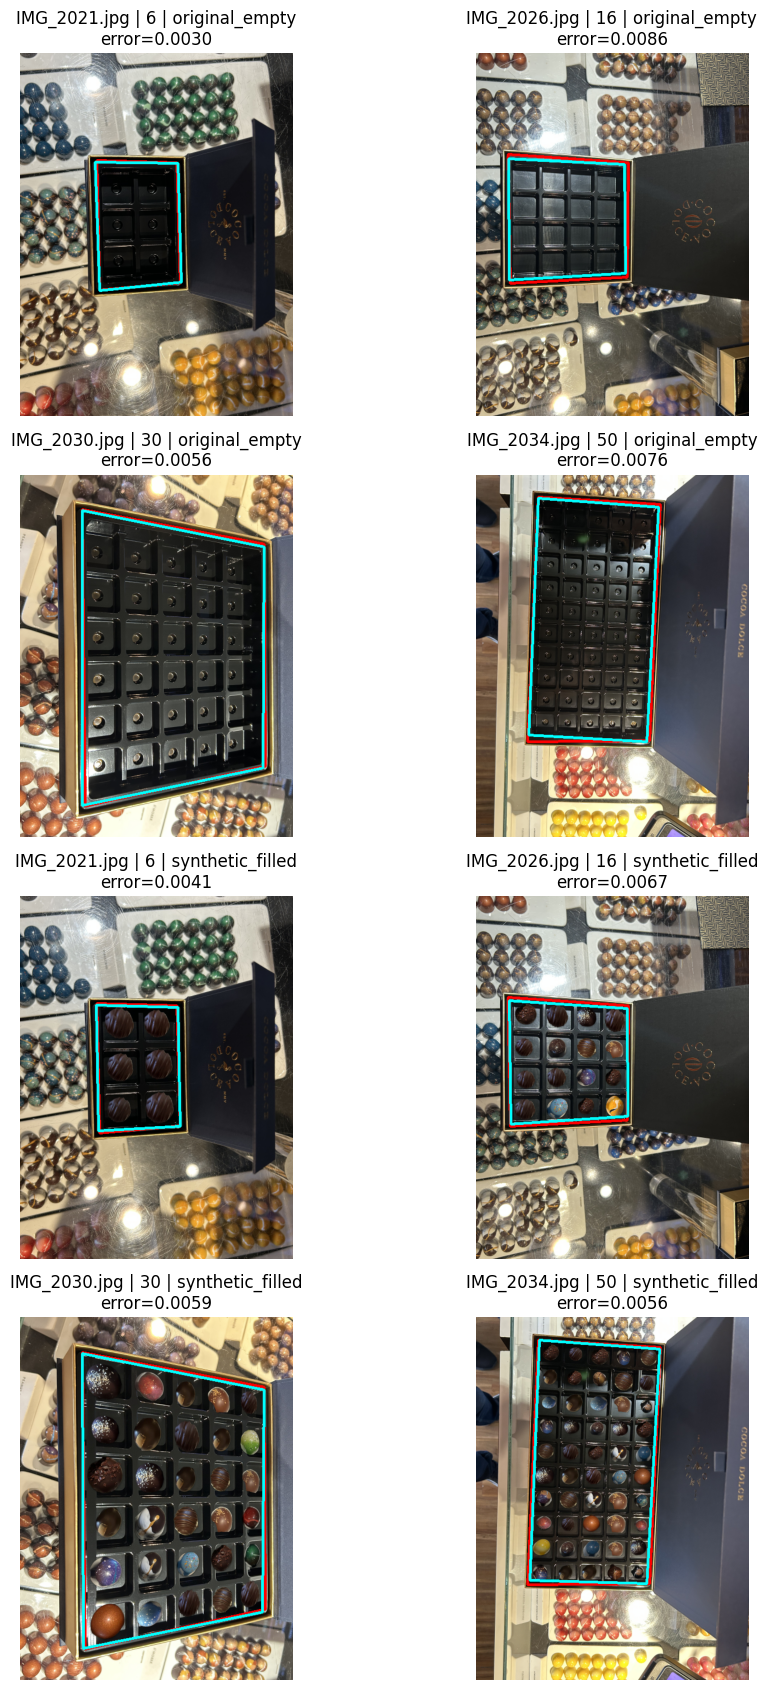

Red: expected manual boundary
Cyan: segmentation-predicted boundary


In [8]:
validation_samples = (
    corner_results[corner_results["split"] == "validation"]
    .groupby("capacity", group_keys=False)
    .head(2)
    .reset_index(drop=True)
)

fig, axes = plt.subplots(4, 2, figsize=(11, 17))

for axis, result in zip(axes.flat, validation_samples.itertuples(index=False)):
    record_row = records[
        (records["source_file"] == result.source_file) &
        (records["kind"] == result.kind)
    ].iloc[0]

    record = SimpleNamespace(**record_row.to_dict())
    rgb, _ = load_image_corners(record)
    h, w = rgb.shape[:2]
    scale = min(650 / max(h, w), 1.0)
    preview = cv2.resize(rgb, (round(w * scale), round(h * scale)), interpolation=cv2.INTER_AREA)

    expected = np.asarray(json.loads(result.expected_corners), np.float32) * scale
    predicted = np.asarray(json.loads(result.predicted_corners), np.float32) * scale

    cv2.polylines(preview, [np.round(expected).astype(np.int32)], True, (255, 0, 0), 4)
    cv2.polylines(preview, [np.round(predicted).astype(np.int32)], True, (0, 255, 255), 3)

    axis.imshow(preview)
    axis.set_title(
        f"{result.source_file} | {result.capacity} | {result.kind}\n"
        f"error={result.corner_error_normalized:.4f}"
    )
    axis.axis("off")

plt.tight_layout()
plt.show()
plt.close(fig)

print("Red: expected manual boundary")
print("Cyan: segmentation-predicted boundary")

In [9]:
import gc
from collections import Counter
from chocolathon_inference import Chocolathon

# Corner predictions are already saved in corner_results, so release the segmenter.
if "model" in globals(): del model
gc.collect()

engine = Chocolathon(PROJECT_ROOT, "cpu", 1, 8, "original", "uniform")
predicted_corner_lookup = {
    row.image: np.asarray(json.loads(row.predicted_corners), np.float32)
    for row in corner_results.itertuples(index=False)
    if row.kind == "synthetic_filled" and row.predicted_corners
}

def load_slot_truth(path):
    with Path(path).open(newline="") as f: rows = list(csv.DictReader(f))
    return {(int(row["row"]), int(row["column"])): row for row in rows}

def score_flavor_result(result, truth):
    predictions = {(int(slot["row"]), int(slot["column"])): slot for slot in result["slots"]}
    expected_counts = Counter(row["flavor_id"] for row in truth.values())
    predicted_counts = Counter(result["flavor_counts"])
    flavor_correct = sum(
        predictions.get(position, {}).get("flavor_id") == target["flavor_id"]
        for position, target in truth.items()
    )
    count_keys = set(expected_counts) | set(predicted_counts)
    return {
        "slots": len(truth),
        "flavor_correct": flavor_correct,
        "flavor_accuracy": flavor_correct / len(truth),
        "count_error": sum(abs(expected_counts[key] - predicted_counts[key]) for key in count_keys),
        "exact_counts": expected_counts == predicted_counts,
        "empty": result["empty"]
    }

with (SYNTH_ROOT / "manifest.csv").open(newline="") as f:
    manifest_rows = list(csv.DictReader(f))

comparison_rows = []

for index, item in enumerate(manifest_rows, 1):
    image_path = resolve_path(item.get("image") or item.get("image_path") or item.get("file"), SYNTH_ROOT)
    gt_path = resolve_path(item.get("gt_path") or item.get("slots_csv") or item.get("ground_truth"), SYNTH_ROOT)
    capacity = int(item.get("box_size") or item.get("capacity"))
    truth = load_slot_truth(gt_path)

    bgr = cv2.imread(str(image_path))
    if bgr is None: raise ValueError(f"Cannot decode {image_path}")
    height, width = bgr.shape[:2]

    predicted_corners = predicted_corner_lookup[image_path.name]
    annotation = {
        "image_width": width,
        "image_height": height,
        "box_size": capacity,
        "corners": {
            name: predicted_corners[position].tolist()
            for position, name in enumerate(CORNER_NAMES)
        }
    }

    automatic, _, _, _ = engine.predict(image_path, filled_only=True)
    segmented, _, _, _ = engine.predict(image_path, annotation=annotation, filled_only=True)

    for mode, result in [("automatic_v2", automatic), ("segmentation", segmented)]:
        metrics = score_flavor_result(result, truth)
        comparison_rows.append({
            "image": image_path.name,
            "source_file": re.search(r"IMG_\d+", image_path.name).group() + ".jpg",
            "capacity": capacity,
            "mode": mode,
            "predicted_capacity": result["predicted_capacity"],
            "capacity_correct": result["predicted_capacity"] == capacity,
            "corner_model": result.get("corner_model", "provided_segmentation"),
            "slots": metrics["slots"],
            "flavor_correct": metrics["flavor_correct"],
            "flavor_accuracy": metrics["flavor_accuracy"],
            "count_error": metrics["count_error"],
            "exact_counts": metrics["exact_counts"],
            "empty": metrics["empty"],
            "seconds": result["seconds"]
        })

    auto = comparison_rows[-2]
    segment = comparison_rows[-1]
    print(
        f"[{index:02d}/{len(manifest_rows)}] {image_path.name}: "
        f"auto={auto['flavor_correct']}/{auto['slots']} err={auto['count_error']} | "
        f"segment={segment['flavor_correct']}/{segment['slots']} err={segment['count_error']}"
    )

deployment_comparison = pd.DataFrame(comparison_rows)
deployment_comparison.to_csv(EXPERIMENT_DIR / "downstream_comparison.csv", index=False)
print("\nPASS: downstream comparison completed")

[01/48] IMG_2019_size6_render00.jpg: auto=6/6 err=0 | segment=6/6 err=0
[02/48] IMG_2019_size6_render01.jpg: auto=6/6 err=0 | segment=6/6 err=0
[03/48] IMG_2019_size6_render02.jpg: auto=6/6 err=0 | segment=6/6 err=0
[04/48] IMG_2020_size6_render00.jpg: auto=5/6 err=2 | segment=6/6 err=0
[05/48] IMG_2020_size6_render01.jpg: auto=5/6 err=2 | segment=6/6 err=0
[06/48] IMG_2020_size6_render02.jpg: auto=4/6 err=4 | segment=6/6 err=0
[07/48] IMG_2021_size6_render00.jpg: auto=6/6 err=0 | segment=6/6 err=0
[08/48] IMG_2021_size6_render01.jpg: auto=6/6 err=0 | segment=6/6 err=0
[09/48] IMG_2021_size6_render02.jpg: auto=6/6 err=0 | segment=6/6 err=0
[10/48] IMG_2022_size16_render00.jpg: auto=16/16 err=0 | segment=16/16 err=0
[11/48] IMG_2022_size16_render01.jpg: auto=16/16 err=0 | segment=16/16 err=0
[12/48] IMG_2022_size16_render02.jpg: auto=12/16 err=8 | segment=16/16 err=0
[13/48] IMG_2023_size16_render00.jpg: auto=16/16 err=0 | segment=16/16 err=0
[14/48] IMG_2023_size16_render01.jpg: auto=1

In [11]:
def summarize_mode(frame):
    slots = frame["slots"].sum()
    return pd.Series({
        "images": len(frame),
        "capacity_accuracy": frame["capacity_correct"].mean(),
        "slot_flavor_accuracy": frame["flavor_correct"].sum() / slots,
        "exact_count_accuracy": frame["exact_counts"].mean(),
        "count_error": frame["count_error"].sum(),
        "false_empty": frame["empty"].sum(),
        "mean_seconds": frame["seconds"].mean()
    })

overall_summary = pd.DataFrame({
    mode: summarize_mode(group)
    for mode, group in deployment_comparison.groupby("mode")
}).T

capacity_summary = pd.concat({
    (capacity, mode): summarize_mode(group)
    for (capacity, mode), group in deployment_comparison.groupby(["capacity", "mode"])
}, axis=1).T

print("OVERALL")
display(overall_summary)

print("\nBY CAPACITY")
display(capacity_summary)

automatic = overall_summary.loc["automatic_v2"]
segmentation = overall_summary.loc["segmentation"]

gates = {
    "flavor_accuracy_improved": bool(segmentation["slot_flavor_accuracy"] > automatic["slot_flavor_accuracy"]),
    "exact_counts_improved": bool(segmentation["exact_count_accuracy"] > automatic["exact_count_accuracy"]),
    "count_error_reduced": bool(segmentation["count_error"] < automatic["count_error"]),
    "false_empty_not_worse": bool(segmentation["false_empty"] <= automatic["false_empty"])
}

for capacity in [6, 16, 30, 50]:
    old = capacity_summary.loc[(capacity, "automatic_v2")]
    new = capacity_summary.loc[(capacity, "segmentation")]
    gates[f"{capacity}_flavor_not_worse"] = bool(new["slot_flavor_accuracy"] >= old["slot_flavor_accuracy"])
    gates[f"{capacity}_count_error_not_worse"] = bool(new["count_error"] <= old["count_error"])

print("\nACCEPTANCE GATES")
print(json.dumps(gates, indent=2))
print("\nAccepted:", all(gates.values()))

OVERALL


,images,capacity_accuracy,slot_flavor_accuracy,exact_count_accuracy,count_error,false_empty,mean_seconds
automatic_v2,48.0,1.0,0.730463,0.4375,286.0,0.0,0.472051
segmentation,48.0,1.0,1.000000,1.0000,0.0,0.0,0.440424



BY CAPACITY


images  capacity_accuracy  slot_flavor_accuracy  \
6  automatic_v2     9.0                1.0              0.925926   
   segmentation     9.0                1.0              1.000000   
16 automatic_v2    15.0                1.0              0.962500   
   segmentation    15.0                1.0              1.000000   
30 automatic_v2    12.0                1.0              0.663889   
   segmentation    12.0                1.0              1.000000   
50 automatic_v2    12.0                1.0              0.660000   
   segmentation    12.0                1.0              1.000000   

                 exact_count_accuracy  count_error  false_empty  mean_seconds  
6  automatic_v2              0.666667          8.0          0.0      0.223875  
   segmentation              1.000000          0.0          0.0      0.161682  
16 automatic_v2              0.800000         14.0          0.0      0.316123  
   segmentation              1.000000          0.0          0.0      0.301296  
30 automatic_v2              0.250000        114.0          0.0      0.517096  
   segmentation              1.000000          0.0          0.0      0.497890  
50 automatic_v2              0.000000        150.0          0.0      0.808048  
   segmentation              1.000000          0.0          0.0      0.765925


ACCEPTANCE GATES
{
  "flavor_accuracy_improved": true,
  "exact_counts_improved": true,
  "count_error_reduced": true,
  "false_empty_not_worse": true,
  "6_flavor_not_worse": true,
  "6_count_error_not_worse": true,
  "16_flavor_not_worse": true,
  "16_count_error_not_worse": true,
  "30_flavor_not_worse": true,
  "30_count_error_not_worse": true,
  "50_flavor_not_worse": true,
  "50_count_error_not_worse": true
}

Accepted: True


In [12]:
import hashlib, shutil

DEPLOYMENT_DIR = EXPERIMENT_DIR / "deployment"
DEPLOYMENT_DIR.mkdir(parents=True, exist_ok=True)

DEPLOYMENT_MODEL = DEPLOYMENT_DIR / "efficientnet_b0_tray_segmenter.pt"
DEPLOYMENT_CONFIG = DEPLOYMENT_DIR / "segmentation_config.json"

shutil.copy2(MODEL_PATH, DEPLOYMENT_MODEL)

config = {
    "architecture": "efficientnet_b0_unet",
    "model_file": DEPLOYMENT_MODEL.name,
    "input_size": INPUT_SIZE,
    "mask_threshold": 0.5,
    "corner_order": CORNER_NAMES,
    "capacities": [6, 16, 30, 50],
    "primary_localizer": "segmentation",
    "fallback_localizer": "routed_corner_regressor",
    "training_images": 48,
    "validation_images": 16,
    "validation_dice": float(best_dice),
    "validation_corner_error_normalized": float(
        corner_results.loc[
            corner_results["split"] == "validation",
            "corner_error_normalized"
        ].mean()
    ),
    "synthetic_v4_exact_count_accuracy": 1.0,
    "synthetic_v4_count_error": 0
}

DEPLOYMENT_CONFIG.write_text(json.dumps(config, indent=2))

sha256 = hashlib.sha256(DEPLOYMENT_MODEL.read_bytes()).hexdigest()
print("Deployment directory:", DEPLOYMENT_DIR)
print("Model:", DEPLOYMENT_MODEL.name)
print("Size:", f"{DEPLOYMENT_MODEL.stat().st_size / 1024**2:.2f} MB")
print("SHA256:", sha256)
print("Config:", DEPLOYMENT_CONFIG.name)
print("\nPASS: segmentation deployment bundle created")

Deployment directory: /homes/mxqasim/Chocolathon/data/experiments/tray_segmentation_v1/deployment
Model: efficientnet_b0_tray_segmenter.pt
Size: 32.58 MB
SHA256: b9017a0cc702877d5c7659f1d3996ae2077d4dec97e8bf9ac31c8dfd0d8fd77d
Config: segmentation_config.json

PASS: segmentation deployment bundle created


In [13]:
deployment_config = json.loads(DEPLOYMENT_CONFIG.read_text())
deployment_checkpoint = torch.load(DEPLOYMENT_MODEL, map_location="cpu")

deployment_model = TraySegmenter(BACKBONE_PATH)
load_result = deployment_model.load_state_dict(
    deployment_checkpoint["model_state_dict"],
    strict=True
)
deployment_model.eval()

test_images, test_masks, _, _ = next(iter(validation_loader))

with torch.no_grad():
    test_outputs = deployment_model(test_images)
    test_probabilities = test_outputs.sigmoid()
    test_predictions = test_probabilities >= deployment_config["mask_threshold"]

assert test_outputs.shape == test_masks.shape
assert torch.isfinite(test_outputs).all()
assert test_predictions.any()
assert deployment_config["input_size"] == INPUT_SIZE
assert deployment_config["corner_order"] == CORNER_NAMES

print("Model load:", load_result)
print("Input:", tuple(test_images.shape))
print("Output:", tuple(test_outputs.shape))
print("Probability range:", float(test_probabilities.min()), "to", float(test_probabilities.max()))
print("Foreground pixels:", int(test_predictions.sum()))
print("\nPASS: staged segmentation deployment model is valid")

Loaded encoder tensors: 358
Encoder missing keys: 0
Model load: <All keys matched successfully>
Input: (4, 3, 320, 320)
Output: (4, 1, 320, 320)
Probability range: 0.1766735166311264 to 0.9091382026672363
Foreground pixels: 105699

PASS: staged segmentation deployment model is valid
